# Day 7 — NLP + Embeddings + Seq2Seq + Attention + Transformers + BERT + GPT

Fine-tuning is intentionally excluded for a separate project later.

## Install Libraries

In [1]:
!pip -q install transformers sentencepiece nltk gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 45.4 MB/s eta 0:00:00


## Imports

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM, pipeline

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## Preprocessing

In [3]:
text = "The cats are running quickly, and they love learning about Artificial Intelligence!"
clean = re.sub(r"[^a-zA-Z\s]", "", text.lower())
tokens = word_tokenize(clean)
stop_words = set(stopwords.words("english"))
filtered = [t for t in tokens if t not in stop_words]
print("Clean:", clean)
print("Tokens:", tokens)
print("Filtered:", filtered)

Clean: the cats are running quickly and they love learning about artificial intelligence
Tokens: ['the', 'cats', 'are', 'running', 'quickly', 'and', 'they', 'love', 'learning', 'about', 'artificial', 'intelligence']
Filtered: ['cats', 'running', 'quickly', 'love', 'learning', 'artificial', 'intelligence']


## Stemming and Lemmatization

In [4]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
print("Stemmed:", [stemmer.stem(w) for w in filtered])
print("Lemmatized:", [lemmatizer.lemmatize(w) for w in filtered])

Stemmed: ['cat', 'run', 'quickli', 'love', 'learn', 'artifici', 'intellig']
Lemmatized: ['cat', 'running', 'quickly', 'love', 'learning', 'artificial', 'intelligence']


## N-Grams

In [5]:
sentence = "I love machine learning"
words = sentence.lower().split()
print("Unigrams:", list(zip(words)))
print("Bigrams:", list(zip(words[:-1], words[1:])))
print("Trigrams:", list(zip(words[:-2], words[1:-1], words[2:])))

Unigrams: [('i',), ('love',), ('machine',), ('learning',)]
Bigrams: [('i', 'love'), ('love', 'machine'), ('machine', 'learning')]
Trigrams: [('i', 'love', 'machine'), ('love', 'machine', 'learning')]


## Bag of Words

In [6]:
docs = ["I love AI","I love machine learning","AI and machine learning are powerful"]
bow = CountVectorizer()
X_bow = bow.fit_transform(docs)
print(bow.get_feature_names_out())
display(pd.DataFrame(X_bow.toarray(), columns=bow.get_feature_names_out()))

['ai' 'and' 'are' 'learning' 'love' 'machine' 'powerful']


,ai,and,are,learning,love,machine,powerful
0,1,0,0,0,1,0,0
1,0,0,0,1,1,1,0
2,1,1,1,1,0,1,1


## TF-IDF

In [7]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(docs)
display(pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out()))

,ai,and,are,learning,love,machine,powerful
0,0.707107,0.000000,0.000000,0.000000,0.707107,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.577350,0.577350,0.577350,0.000000
2,0.349498,0.459548,0.459548,0.349498,0.000000,0.349498,0.459548


## TF-IDF Formula

In [8]:
print("TF-IDF(t,d) = TF(t,d) * IDF(t)")

TF-IDF(t,d) = TF(t,d) * IDF(t)


## Cosine Similarity

In [9]:
A = np.array([[1,2,3]])
B = np.array([[1,2,2]])
print("Cosine similarity:", cosine_similarity(A,B)[0][0])

Cosine similarity: 0.9799578870122228


## Word2Vec CBOW

In [10]:
sentences = [
    ["king","queen","royal","palace"],
    ["man","woman","king","queen"],
    ["dog","cat","pet","animal"],
    ["machine","learning","ai","data"],
    ["deep","learning","neural","network"]
]
cbow = Word2Vec(sentences=sentences, vector_size=20, window=3, min_count=1, sg=0, epochs=100)
print(cbow.wv["king"][:5])

[-0.04813309  0.02496788 -0.04389183 -0.02198343 -0.00015534]


## Word2Vec Skip-Gram

In [11]:
skipgram = Word2Vec(sentences=sentences, vector_size=20, window=3, min_count=1, sg=1, epochs=100)
print(skipgram.wv["king"][:5])

[-4.8157085e-02  2.4976449e-02 -4.3932933e-02 -2.2042753e-02
 -8.3885374e-05]


## CBOW vs Skip-Gram

In [12]:
print("CBOW: context -> target word")
print("Skip-Gram: target word -> context")

CBOW: context -> target word
Skip-Gram: target word -> context


## GloVe Concept

In [13]:
print("GloVe: global co-occurrence embeddings")
print("Word2Vec: local context prediction")

GloVe: global co-occurrence embeddings
Word2Vec: local context prediction


## Seq2Seq Encoder

In [14]:
encoder_inputs = layers.Input(shape=(8,16))
encoder_lstm = layers.LSTM(32, return_state=True)
encoder_output, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_model = keras.Model(encoder_inputs, [state_h, state_c])
encoder_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ [(None, 32), (None,    │         6,272 │
│                                 │ 32), (None, 32)]       │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,272 (24.50 KB)

 Trainable params: 6,272 (24.50 KB)

 Non-trainable params: 0 (0.00 B)

## Seq2Seq Decoder

In [15]:
decoder_inputs = layers.Input(shape=(6,16))
state_h_in = layers.Input(shape=(32,))
state_c_in = layers.Input(shape=(32,))
decoder_lstm = layers.LSTM(32, return_sequences=True, return_state=True)
decoder_out, _, _ = decoder_lstm(decoder_inputs, initial_state=[state_h_in, state_c_in])
decoder_out = layers.Dense(16)(decoder_out)
decoder_model = keras.Model([decoder_inputs, state_h_in, state_c_in], decoder_out)
decoder_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 6, 16)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 6, 32),   │      6,272 │ input_layer_1[0]… │
│                     │ (None, 32),       │            │ input_layer_2[0]… │
│                     │ (None, 32)]       │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6, 16)     │        528 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,800 (26.56 KB)

 Trainable params: 6,800 (26.56 KB)

 Non-trainable params: 0 (0.00 B)

## Teacher Forcing Concept

In [16]:
print("Training: correct previous token -> decoder")
print("Inference: previous predicted token -> decoder")

Training: correct previous token -> decoder
Inference: previous predicted token -> decoder


## Scaled Dot-Product Attention

In [17]:
def scaled_dot_product_attention(Q,K,V):
    dk = tf.cast(tf.shape(K)[-1], tf.float32)
    scores = tf.matmul(Q, K, transpose_b=True) / tf.math.sqrt(dk)
    weights = tf.nn.softmax(scores, axis=-1)
    return tf.matmul(weights, V), weights

Q = tf.random.normal((1,3,4))
K = tf.random.normal((1,3,4))
V = tf.random.normal((1,3,4))
out, weights = scaled_dot_product_attention(Q,K,V)
print("Output:", out.shape)
print("Weights:", weights.numpy())

Output: (1, 3, 4)
Weights: [[[0.5820058  0.35102352 0.0669706 ]
  [0.50109416 0.22475958 0.27414632]
  [0.7088469  0.09994869 0.1912044 ]]]


## Attention Formula

In [18]:
print("Attention(Q,K,V) = softmax((QK^T)/sqrt(d_k))V")

Attention(Q,K,V) = softmax((QK^T)/sqrt(d_k))V


## Self-Attention QKV

In [19]:
X = tf.random.normal((1,5,8))
Q = layers.Dense(8)(X)
K = layers.Dense(8)(X)
V = layers.Dense(8)(X)
print(Q.shape, K.shape, V.shape)

(1, 5, 8) (1, 5, 8) (1, 5, 8)


## Multi-Head Attention

In [20]:
mha = layers.MultiHeadAttention(num_heads=2, key_dim=4)
X = tf.random.normal((1,5,8))
print(mha(X,X).shape)

(1, 5, 8)


## Positional Encoding

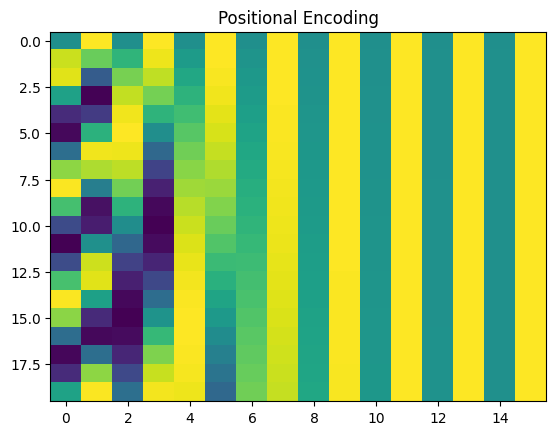

In [21]:
def positional_encoding(seq_len, d_model):
    positions = np.arange(seq_len)[:,None]
    dims = np.arange(d_model)[None,:]
    angle_rates = 1 / np.power(10000, (2*(dims//2))/np.float32(d_model))
    angles = positions * angle_rates
    pe = np.zeros((seq_len,d_model))
    pe[:,0::2] = np.sin(angles[:,0::2])
    pe[:,1::2] = np.cos(angles[:,1::2])
    return pe

pe = positional_encoding(20,16)
plt.imshow(pe, aspect="auto")
plt.title("Positional Encoding")
plt.show()

## Transformer Encoder Block

In [22]:
class TransformerEncoderBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim):
        super().__init__()
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads)
        self.ffn = keras.Sequential([layers.Dense(ff_dim, activation="relu"), layers.Dense(d_model)])
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()
    def call(self, x):
        a = self.attn(x,x)
        x = self.norm1(x+a)
        f = self.ffn(x)
        return self.norm2(x+f)

block = TransformerEncoderBlock(32,4,64)
x = tf.random.normal((2,10,32))
print(block(x).shape)

(2, 10, 32)


## BERT Tokenization

In [23]:
bert_name = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_name)
tokens = bert_tokenizer("Transformers understand context.", return_tensors="pt")
print(tokens)
print(bert_tokenizer.convert_ids_to_tokens(tokens["input_ids"][0]))

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

{'input_ids': tensor([[  101, 19081,  3305,  6123,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}
['[CLS]', 'transformers', 'understand', 'context', '.', '[SEP]']


## BERT Base Model

In [24]:
bert_model = AutoModel.from_pretrained("bert-base-uncased")
outputs = bert_model(**tokens)
print(outputs.last_hidden_state.shape)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([1, 6, 768])


## BERT Concept

In [25]:
print("BERT = encoder-only, bidirectional, masked-language-model pretraining")

BERT = encoder-only, bidirectional, masked-language-model pretraining


## Hugging Face Sentiment Pipeline

In [26]:
sentiment = pipeline("sentiment-analysis")
print(sentiment("I really enjoyed learning transformers."))

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.999714195728302}]


## GPT Tokenization

In [27]:
gpt_name = "distilgpt2"
gpt_tokenizer = AutoTokenizer.from_pretrained(gpt_name)
gpt_model = AutoModelForCausalLM.from_pretrained(gpt_name)
inputs = gpt_tokenizer("Artificial intelligence is", return_tensors="pt")
print(inputs)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

{'input_ids': tensor([[8001, 9542, 4430,  318]]), 'attention_mask': tensor([[1, 1, 1, 1]])}


## GPT Generation

In [28]:
generated = gpt_model.generate(
    **inputs,
    max_new_tokens=25,
    do_sample=True,
    temperature=0.8,
    pad_token_id=gpt_tokenizer.eos_token_id
)
print(gpt_tokenizer.decode(generated[0], skip_special_tokens=True))

Artificial intelligence is the world’s most widely used technology.


## BERT vs GPT

In [29]:
display(pd.DataFrame({
    "Feature":["Architecture","Context","Training Idea","Main Strength"],
    "BERT":["Encoder-only","Bidirectional","Masked LM","Understanding"],
    "GPT":["Decoder-only","Autoregressive","Next-token prediction","Generation"]
}))

,Feature,BERT,GPT
0,Architecture,Encoder-only,Decoder-only
1,Context,Bidirectional,Autoregressive
2,Training Idea,Masked LM,Next-token prediction
3,Main Strength,Understanding,Generation


## Final Summary

In [30]:
display(pd.DataFrame({
    "Topic":["BoW","TF-IDF","Word2Vec","CBOW","Skip-Gram","GloVe","Seq2Seq","Attention","Transformer","BERT","GPT","Hugging Face"],
    "Memory Point":["Word counts","Weighted importance","Learned embeddings","Context->word","Word->context","Global co-occurrence","Sequence->sequence","Focus on relevant tokens","Attention-based model","Encoder-only","Decoder-only","Pretrained models + pipelines"]
}))

,Topic,Memory Point
0,BoW,Word counts
1,TF-IDF,Weighted importance
2,Word2Vec,Learned embeddings
3,CBOW,Context->word
4,Skip-Gram,Word->context
5,GloVe,Global co-occurrence
6,Seq2Seq,Sequence->sequence
7,Attention,Focus on relevant tokens
8,Transformer,Attention-based model
9,BERT,Encoder-only
